# Sífilis em Ilhéus e Itabuna - qualidade e consistência

Este notebook verifica completude, campos ausentes, datas, anos e diferenças de preenchimento entre os três tipos de sífilis.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def encontrar_projeto():
    for candidato in [Path.cwd(), *Path.cwd().parents]:
        if (candidato / "Dados").exists() and (candidato / "Sifilis").exists():
            return candidato
        if (candidato / "DataSUS" / "Dados").exists():
            return candidato / "DataSUS"
    raise FileNotFoundError("Não foi possível localizar a pasta DataSUS.")

PROJECT_DIR = encontrar_projeto()
SIFILIS_DIR = PROJECT_DIR / "Sifilis"
DATA_DIR = PROJECT_DIR / "Dados"
OUTPUT_DIR = SIFILIS_DIR / "dados_processados"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SIFILIS_DIR) not in sys.path:
    sys.path.insert(0, str(SIFILIS_DIR))

from sifilis_utils import (
    ANOS_ESPERADOS,
    CODIGOS_CIDADES,
    TIPOS_SIFILIS,
    carregar_agregados_demograficos,
    carregar_agregados_especificos,
    carregar_agregados_qualidade,
    carregar_agregados_temporais,
    carregar_base_cidades,
    caminho_artefato,
    exigir_cache_processado,
    exibir_markdown,
    formatar_inteiro,
    formatar_percentual,
    ler_tabela,
    salvar_figura,
    verificar_cache_processado,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

exigir_cache_processado(OUTPUT_DIR)

qualidade = carregar_agregados_qualidade(OUTPUT_DIR)
resumo_arquivos = qualidade["sifilis_resumo_arquivos"]
checagem = qualidade["sifilis_qualidade_checagem_arquivos"]
completude = qualidade["sifilis_qualidade_completude_campos"]
data_quality = qualidade["sifilis_qualidade_datas"]
nao_informado = qualidade["sifilis_qualidade_nao_informado"]
comparacao_2024 = qualidade["sifilis_comparacao_2024"]

## Conferência de arquivos e anos

In [2]:
checagem

,tipo_sifilis,arquivos,primeiro_ano,ultimo_ano,linhas_bahia,linhas_cidades
0,Sífilis adquirida,11,2014,2024,65723,2209
1,Sífilis congênita,11,2014,2024,13621,432
2,Sífilis em gestante,11,2014,2024,35002,1169


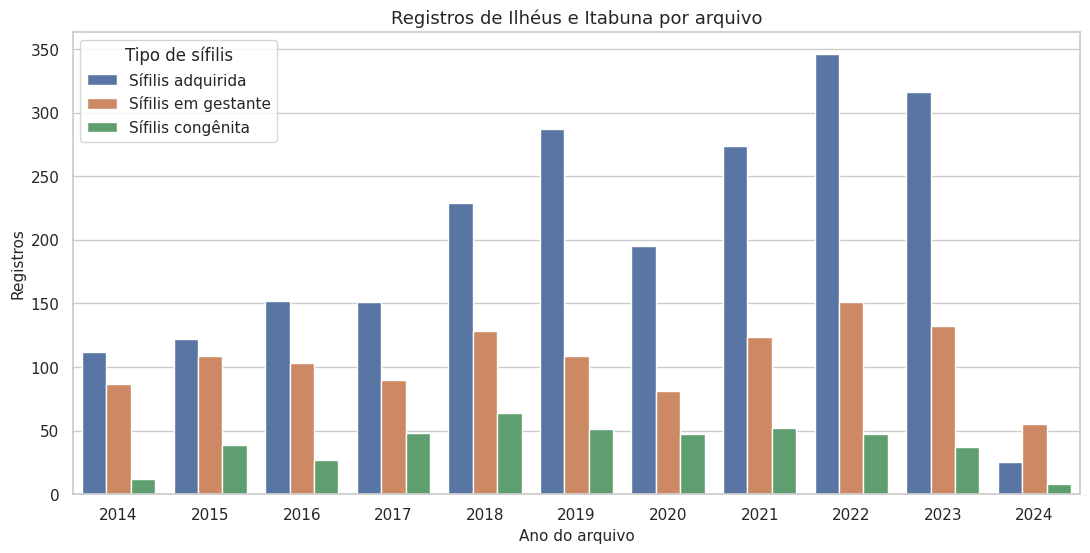

In [3]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=resumo_arquivos, x="ano_arquivo", y="linhas_ilheus_itabuna", hue="tipo_sifilis", ax=ax)
ax.set_title("Registros de Ilhéus e Itabuna por arquivo")
ax.set_xlabel("Ano do arquivo")
ax.set_ylabel("Registros")
ax.legend(title="Tipo de sífilis")
salvar_figura(fig, OUTPUT_DIR, "02_registros_por_arquivo.png")
plt.show()

## Completude dos campos principais

In [4]:
completude

,tipo_sifilis,campo,ausencia_pct
0,Sífilis adquirida,data_notificacao,0.000000
1,Sífilis adquirida,data_diagnostico,0.000000
2,Sífilis adquirida,idade_anos,0.000000
3,Sífilis adquirida,sexo,0.000000
4,Sífilis adquirida,raca_cor,0.000000
5,Sífilis adquirida,escolaridade,0.000000
6,Sífilis adquirida,gestante,0.045269
7,Sífilis adquirida,classificacao_final,0.995926
8,Sífilis adquirida,criterio_confirmacao,17.021277
9,Sífilis adquirida,evolucao,17.790856


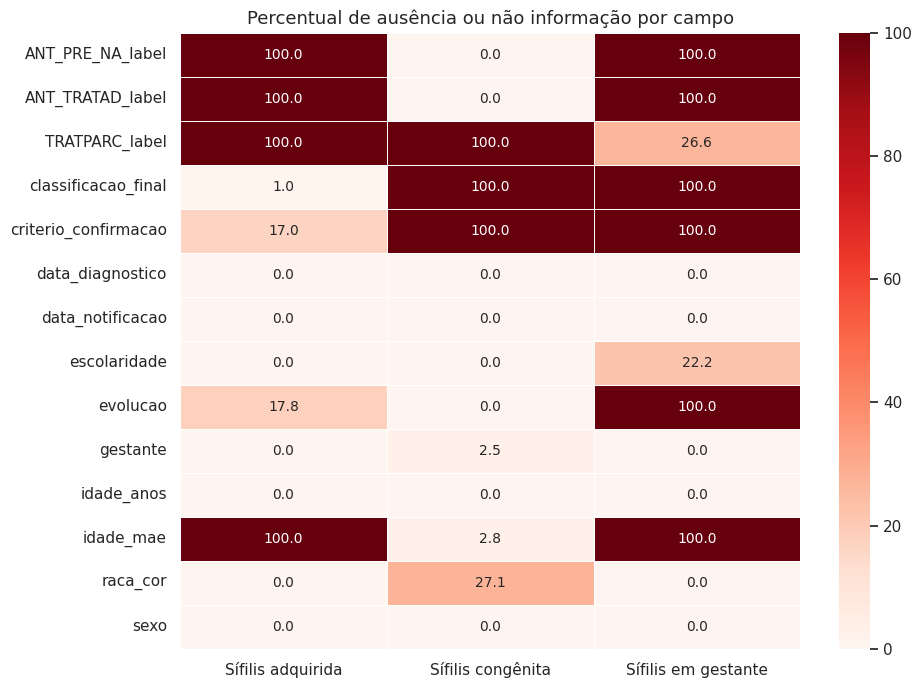

In [5]:
matriz = completude.pivot(index="campo", columns="tipo_sifilis", values="ausencia_pct")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matriz, annot=True, fmt=".1f", cmap="Reds", linewidths=.4, ax=ax)
ax.set_title("Percentual de ausência ou não informação por campo")
ax.set_xlabel("")
ax.set_ylabel("")
salvar_figura(fig, OUTPUT_DIR, "02_heatmap_ausencia_campos.png")
plt.show()

## Datas, anos e registros sem período mensal

In [6]:
data_quality

,tipo_sifilis,cidade,registros,sem_data_notificacao,sem_periodo,ano_diferente_arquivo
0,Sífilis adquirida,Ilhéus,714,0,0,0
1,Sífilis adquirida,Itabuna,1495,0,0,0
2,Sífilis congênita,Ilhéus,316,0,0,0
3,Sífilis congênita,Itabuna,116,0,0,0
4,Sífilis em gestante,Ilhéus,564,0,0,0
5,Sífilis em gestante,Itabuna,605,0,0,0


## Categorias não informadas

In [7]:
nao_informado

,tipo_sifilis,campo,nao_informado_pct
0,Sífilis adquirida,sexo,0.135808
1,Sífilis adquirida,raca_cor,24.852875
2,Sífilis adquirida,escolaridade,0.000000
3,Sífilis adquirida,gestante,7.152558
4,Sífilis adquirida,classificacao_final,0.995926
5,Sífilis adquirida,evolucao,35.445903
6,Sífilis congênita,sexo,3.472222
7,Sífilis congênita,raca_cor,44.675926
8,Sífilis congênita,escolaridade,0.000000
9,Sífilis congênita,gestante,2.777778


## Leitura de 2024

In [8]:
colunas_anos = [coluna for coluna in ["2021", "2022", "2023", "2024"] if coluna in comparacao_2024.columns]
comparacao_2024[["cidade", "tipo_sifilis", *colunas_anos, "media_2021_2023", "razao_2024_media_2021_2023"]]

,cidade,tipo_sifilis,2021,2022,2023,2024,media_2021_2023,razao_2024_media_2021_2023
0,Ilhéus,Sífilis adquirida,101,183,163,24,149.000000,0.161074
1,Ilhéus,Sífilis congênita,42,38,22,8,34.000000,0.235294
2,Ilhéus,Sífilis em gestante,78,99,79,35,85.333333,0.410156
3,Itabuna,Sífilis adquirida,173,163,153,1,163.000000,0.006135
4,Itabuna,Sífilis congênita,10,9,15,0,11.333333,0.000000
5,Itabuna,Sífilis em gestante,46,52,53,20,50.333333,0.397351


In [9]:
menor_razao = comparacao_2024["razao_2024_media_2021_2023"].min()

Em todos os gráficos temporais, 2024 deve ser lido com cautela. No menor grupo, o total de 2024 corresponde a 0,0% da média de 2021 a 2023. Essa diferença pode refletir atualização parcial da base, atraso de processamento ou mudança no fechamento dos arquivos.